# 03 - Analise exploratoria dos dados interim

Esta segunda analise olha para os dados em `data/interim`, antes do preprocessamento usado para modelagem. O objetivo e entender a base como ela chega ao projeto: qualidade, descricoes de produtos, NCM, relacao entre descricao e NCM, e contexto da compra.

A analise separa as linhas de item usando a presenca da coluna de descricao do produto/servico. Isso e importante porque os arquivos interim tambem podem conter linhas com metadados da nota fiscal, nas quais as colunas de item ficam vazias.

In [1]:
from pathlib import Path
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

DATASET_NAME = os.getenv("DATASET_NAME", "items-notas-fiscais")

# Sobresecreve analise
DATASET_NAME = "items-notas-fiscais-filtros-combinados"

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
ITEMS_DIR = INTERIM_DIR / DATASET_NAME

UNIQUE_ITEMS_PATH = INTERIM_DIR / "items-unicos" / DATASET_NAME / "produtos-unicos.csv"
LEGACY_UNIQUE_ITEMS_PATH = INTERIM_DIR / "items-unicos" / "produtos-unicos-202501-202504.csv"
if DATASET_NAME == "items-notas-fiscais" and not UNIQUE_ITEMS_PATH.exists():
    UNIQUE_ITEMS_PATH = LEGACY_UNIQUE_ITEMS_PATH

parquet_paths = sorted(ITEMS_DIR.glob("*.parquet"))
{
    "DATASET_NAME": DATASET_NAME,
    "ITEMS_DIR": ITEMS_DIR,
    "UNIQUE_ITEMS_PATH": UNIQUE_ITEMS_PATH,
    "parquet_files": parquet_paths,
}

{'DATASET_NAME': 'items-notas-fiscais-filtros-combinados',
 'ITEMS_DIR': WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais-filtros-combinados'),
 'UNIQUE_ITEMS_PATH': WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-unicos/items-notas-fiscais-filtros-combinados/produtos-unicos.csv'),
 'parquet_files': [WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais-filtros-combinados/2025-01.parquet'),
  WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais-filtros-combinados/2025-02.parquet'),
  WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais-filtros-combinados/2025-03.parquet'),
  WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais-filtros-combinados/2025-04.parquet')]}

In [2]:
def find_col(columns, *patterns):
    """Return the first column whose uppercase name contains all informed patterns."""
    normalized = {col: str(col).upper() for col in columns}
    for col, upper in normalized.items():
        if all(pattern.upper() in upper for pattern in patterns):
            return col
    raise KeyError(f"Nenhuma coluna encontrada para os padroes: {patterns}")


def optional_col(columns, *patterns):
    """Return a matching column or None when the source file does not provide it."""
    try:
        return find_col(columns, *patterns)
    except KeyError:
        return None


def to_number_br(series):
    """Convert Brazilian numeric strings such as '1.234,56' to float."""
    return pd.to_numeric(
        series.astype("string")
        .str.strip()
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    )


def pct(series):
    """Format a ratio as percentage."""
    return (100 * series).round(2)

## Carregamento

Os arquivos mensais em Parquet sao combinados em um unico `DataFrame`. A coluna `mes_arquivo` e derivada do nome do arquivo para permitir comparacoes temporais simples.

In [3]:
if not parquet_paths:
    raise FileNotFoundError(f"Nenhum Parquet encontrado em {ITEMS_DIR}")

frames = []
for path in parquet_paths:
    month_df = pd.read_parquet(path)
    month_df["mes_arquivo"] = path.stem
    frames.append(month_df)

df = pd.concat(frames, ignore_index=True)
df.shape

(134625, 40)

In [4]:
desc_col = find_col(df.columns, "PRODUTO/SERV")
ncm_col = find_col([col for col in df.columns if "TIPO" not in str(col).upper()], "NCM/SH")
ncm_tipo_col = optional_col(df.columns, "NCM/SH", "TIPO")
emitente_col = optional_col(df.columns, "SOCIAL", "EMITENTE")
cnpj_emitente_col = optional_col(df.columns, "CPF/CNPJ", "EMITENTE")
uf_col = optional_col(df.columns, "UF", "EMITENTE")
municipio_col = optional_col(df.columns, "MUNIC", "EMITENTE")
unidade_col = optional_col(df.columns, "UNIDADE")
quantidade_col = optional_col(df.columns, "QUANTIDADE")
valor_unitario_col = optional_col(df.columns, "VALOR", "UNIT")
valor_total_col = optional_col(df.columns, "VALOR", "TOTAL")
valor_nota_col = optional_col(df.columns, "VALOR", "NOTA")
chave_col = optional_col(df.columns, "CHAVE")

cols = {
    "descricao": desc_col,
    "ncm": ncm_col,
    "ncm_tipo": ncm_tipo_col,
    "emitente": emitente_col,
    "cnpj_emitente": cnpj_emitente_col,
    "uf_emitente": uf_col,
    "municipio_emitente": municipio_col,
    "unidade": unidade_col,
    "quantidade": quantidade_col,
    "valor_unitario": valor_unitario_col,
    "valor_total": valor_total_col,
    "valor_nota": valor_nota_col,
    "chave_acesso": chave_col,
}
pd.Series(cols, name="coluna_detectada")

descricao             DESCRIÇÃO DO PRODUTO/SERVIÇO
ncm                                  CÓDIGO NCM/SH
ncm_tipo                  NCM/SH (TIPO DE PRODUTO)
emitente                     RAZÃO SOCIAL EMITENTE
cnpj_emitente                    CPF/CNPJ Emitente
uf_emitente                            UF EMITENTE
municipio_emitente              MUNICÍPIO EMITENTE
unidade                                    UNIDADE
quantidade                              QUANTIDADE
valor_unitario                      VALOR UNITÁRIO
valor_total                            VALOR TOTAL
valor_nota                       VALOR NOTA FISCAL
chave_acesso                       CHAVE DE ACESSO
Name: coluna_detectada, dtype: str

In [5]:
items = df[df[desc_col].notna()].copy()
items["descricao_limpa_minima"] = items[desc_col].astype("string").str.strip().str.lower()
items["ncm_str"] = items[ncm_col].astype("string").str.replace(r"\.0$", "", regex=True).str.zfill(8)
items.loc[items[ncm_col].isna(), "ncm_str"] = pd.NA

if quantidade_col:
    items["quantidade_num"] = to_number_br(items[quantidade_col])
if valor_unitario_col:
    items["valor_unitario_num"] = to_number_br(items[valor_unitario_col])
if valor_total_col:
    items["valor_total_num"] = to_number_br(items[valor_total_col])
if valor_nota_col:
    items["valor_nota_num"] = to_number_br(items[valor_nota_col])

items.shape

(134625, 46)

In [6]:
descricoes_unicas_filtradas = items["descricao_limpa_minima"].nunique()
print(f"Descricoes unicas na base filtrada: {descricoes_unicas_filtradas:,}".replace(",", "."))

Descricoes unicas na base filtrada: 28.576


In [7]:
MAX_EXAMPLE_ROWS = 200_000
MAX_RELATION_ROWS = 75_000
items_for_examples = items.sample(n=min(len(items), MAX_EXAMPLE_ROWS), random_state=42) if len(items) else items
items_for_relation = items.sample(n=min(len(items), MAX_RELATION_ROWS), random_state=7) if len(items) else items
items_for_examples.shape

(134625, 46)

## 1. Qualidade da base

**Por que importa para o TCC:** identifica problemas antes do processamento, como ausencia de campos relevantes, duplicatas e diferencas entre meses.

In [8]:
resumo_geral = pd.DataFrame(
    {
        "metrica": [
            "linhas totais",
            "colunas",
            "linhas de item com descricao",
            "percentual de linhas de item",
            "duplicatas exatas no dataframe completo",
            "duplicatas exatas entre itens",
        ],
        "valor": [
            len(df),
            df.shape[1],
            len(items),
            f"{len(items) / len(df):.2%}",
            int(df.duplicated().sum()),
            int(items.duplicated().sum()),
        ],
    }
)
resumo_geral

,metrica,valor
0,linhas totais,134625
1,colunas,40
2,linhas de item com descricao,134625
3,percentual de linhas de item,100.00%
4,duplicatas exatas no dataframe completo,0
5,duplicatas exatas entre itens,0


In [9]:
linhas_por_mes = (
    df.groupby("mes_arquivo")
    .agg(
        linhas=(desc_col, "size"),
        linhas_item=(desc_col, lambda s: int(s.notna().sum())),
        descricoes_unicas=(desc_col, "nunique"),
        ncms_unicos=(ncm_col, "nunique"),
    )
    .assign(percentual_item=lambda d: pct(d["linhas_item"] / d["linhas"]))
)
linhas_por_mes

,linhas,linhas_item,descricoes_unicas,ncms_unicos,percentual_item
mes_arquivo,,,,,
2025-01,25790,25790,8582,527,100.0
2025-02,29289,29289,10431,558,100.0
2025-03,37932,37932,12061,563,100.0
2025-04,41614,41614,12820,575,100.0


In [10]:
tipos_e_ausentes = pd.DataFrame(
    {
        "coluna": df.columns,
        "tipo": [str(dtype) for dtype in df.dtypes],
        "ausentes_total": df.isna().sum().to_numpy(),
        "ausentes_total_pct": pct(df.isna().mean()).to_numpy(),
        "ausentes_itens_pct": pct(items.reindex(columns=df.columns).isna().mean()).to_numpy(),
    }
).sort_values("ausentes_itens_pct", ascending=False)
tipos_e_ausentes

,coluna,tipo,ausentes_total,ausentes_total_pct,ausentes_itens_pct
6,EVENTO MAIS RECENTE,str,134625,100.00,100.00
7,DATA/HORA EVENTO MAIS RECENTE,str,134625,100.00,100.00
27,DATA/HORA EVENTO,object,134625,100.00,100.00
24,VALOR NOTA FISCAL,str,134625,100.00,100.00
29,MOTIVO EVENTO,object,134625,100.00,100.00
26,EVENTO,object,134625,100.00,100.00
28,DESCRIÇÃO EVENTO,object,134625,100.00,100.00
33,NCM/SH (TIPO DE PRODUTO),str,4831,3.59,3.59
36,UNIDADE,str,11,0.01,0.01
5,DATA EMISSÃO,str,0,0.00,0.00


In [11]:
subset_duplicatas = [col for col in [desc_col, ncm_col, unidade_col, valor_total_col] if col]
duplicatas_por_chave = (
    items.groupby(subset_duplicatas, dropna=False)
    .size()
    .reset_index(name="ocorrencias")
    .sort_values("ocorrencias", ascending=False)
    .head(20)
)
duplicatas_por_chave

,DESCRIÇÃO DO PRODUTO/SERVIÇO,CÓDIGO NCM/SH,UNIDADE,VALOR TOTAL,ocorrencias
12951,BANANA PRATA,8039000.0,KG,"436,80",49
48555,LEITE DE VACA EM PO INTEGRAL - ACOND.: P - EANTrib.: 7898163680244,4022110.0,KG,"2082,50",43
36678,FARINHA DE TRIGO ENRIQUECIDA TIPO 1 - ACOND.: P - EANTrib.: 7896956410948,11010010.0,KG,"156,10",43
16648,BETERRABA,17011200.0,KG,"98,00",43
56906,MELANCIA,8071100.0,KG,"187,50",40
1224,ABACAXI PEROLA,8031000.0,KG,"64,80",39
23730,CEBOLINHA,7039090.0,UNIDAD,"12,50",38
23309,CEBOLA COMUM MC S/A,7031019.0,KG,"57,80",37
68980,PIMENTAO VERMELHO,7096000.0,KG,"81,30",35
27301,COENTRO,7052900.0,MOL,"19,00",35


## 2. Descricoes dos produtos

**Por que importa para o TCC:** caracteriza o problema de classificacao sobre textos curtos, ruidosos, abreviados e com padroes variados.

In [12]:
desc = items[desc_col].astype("string").str.strip()
desc_stats = pd.DataFrame(
    {
        "metrica": [
            "descricoes preenchidas",
            "descricoes unicas",
            "taxa de repeticao",
            "media de caracteres",
            "mediana de caracteres",
            "media de palavras",
            "mediana de palavras",
            "com numeros (%)",
            "com caracteres nao alfanumericos (%)",
        ],
        "valor": [
            int(desc.notna().sum()),
            int(desc.nunique()),
            f"{1 - desc.nunique() / desc.notna().sum():.2%}",
            round(desc.str.len().mean(), 2),
            round(desc.str.len().median(), 2),
            round(desc.str.split().str.len().mean(), 2),
            round(desc.str.split().str.len().median(), 2),
            round(100 * desc.str.contains(r"\d", regex=True, na=False).mean(), 2),
            round(100 * desc.str.contains(r"[^\w\s]", regex=True, na=False).mean(), 2),
        ],
    }
)
desc_stats

,metrica,valor
0,descricoes preenchidas,134625
1,descricoes unicas,29043
2,taxa de repeticao,78.43%
3,media de caracteres,22.45
4,mediana de caracteres,19.0
5,media de palavras,3.82
6,mediana de palavras,3.0
7,com numeros (%),35.25
8,com caracteres nao alfanumericos (%),28.38


In [13]:
freq_descricoes = desc.value_counts().rename_axis("descricao").reset_index(name="ocorrencias")
freq_descricoes.head(30)

,descricao,ocorrencias
0,CENOURA,1473
1,BETERRABA,1364
2,MELANCIA,1210
3,BATATA INGLESA,964
4,BATATA DOCE,839
5,BANANA PRATA,805
6,PIMENTAO VERDE,758
7,ALFACE CRESPA,695
8,CEBOLA,632
9,ABOBORA,598


In [14]:
items["descricao_tamanho"] = desc.str.len()
items["descricao_palavras"] = desc.str.split().str.len()
items["descricao_tem_numero"] = desc.str.contains(r"\d", regex=True, na=False)
items["descricao_tem_caractere_especial"] = desc.str.contains(r"[^\w\s]", regex=True, na=False)

items[["descricao_tamanho", "descricao_palavras"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,descricao_tamanho,descricao_palavras
count,134625.0,134625.000000
mean,22.45216,3.815138
std,15.888378,2.670475
min,1.0,1.000000
1%,4.0,1.000000
5%,6.0,1.000000
25%,12.0,2.000000
50%,19.0,3.000000
75%,28.0,5.000000
95%,53.0,9.000000


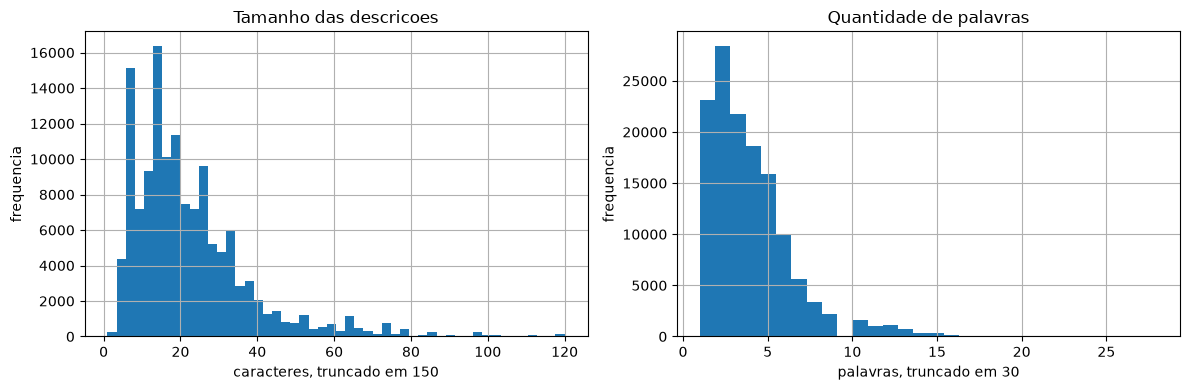

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
items["descricao_tamanho"].clip(upper=150).hist(bins=50, ax=axes[0])
axes[0].set_title("Tamanho das descricoes")
axes[0].set_xlabel("caracteres, truncado em 150")
axes[0].set_ylabel("frequencia")

items["descricao_palavras"].clip(upper=30).hist(bins=30, ax=axes[1])
axes[1].set_title("Quantidade de palavras")
axes[1].set_xlabel("palavras, truncado em 30")
axes[1].set_ylabel("frequencia")
plt.tight_layout()

In [16]:
exemplos_descricoes = pd.concat(
    [
        items.nsmallest(10, "descricao_tamanho")[[desc_col, "descricao_tamanho", "descricao_palavras", "ncm_str"]].assign(grupo="mais curtas"),
        items.nlargest(10, "descricao_tamanho")[[desc_col, "descricao_tamanho", "descricao_palavras", "ncm_str"]].assign(grupo="mais longas"),
    ],
    ignore_index=True,
)
exemplos_descricoes

,DESCRIÇÃO DO PRODUTO/SERVIÇO,descricao_tamanho,descricao_palavras,ncm_str,grupo
0,.,1,1,22011000,mais curtas
1,UVA,3,1,08061000,mais curtas
2,OVO,3,1,10059010,mais curtas
3,OVO,3,1,10059010,mais curtas
4,UVA,3,1,08061000,mais curtas
5,OVO,3,1,04072900,mais curtas
6,OVO,3,1,04072900,mais curtas
7,UVA,3,1,08061000,mais curtas
8,Uva,3,1,08061000,mais curtas
9,UVA,3,1,08061000,mais curtas


In [17]:
if UNIQUE_ITEMS_PATH.exists():
    produtos_unicos = pd.read_csv(UNIQUE_ITEMS_PATH)
    display(produtos_unicos.shape)
    display(produtos_unicos.head(20))
else:
    produtos_unicos = None
    print(f"Arquivo nao encontrado: {UNIQUE_ITEMS_PATH}")

(29043, 1)

,nome_produto
0,#1700100#17049010#TAB LC BRANCO 5
1,#1700300#18063210#TAB BT CAC 85% 5G
2,#1700300#18063210#TAB CS CAFE 5
3,"#1700700#18069000#BB PD BEIJINH 12,5"
4,"#1700700#18069000#BB PD BEM CAS 12,5"
5,"#1700700#18069000#BB PD HOLAND 12,5"
6,"#1700700#18069000#BB PD MIL FOL 11,5"
7,#1700700#18069000#CX ANG FRU SILV 75
8,#1700700#18069000#CX GOURMET 465
9,"#1700900#18069000#BB PD BRIGAD 11,5"


## 3. NCM

**Por que importa para o TCC:** permite investigar quanto conhecimento estruturado ja existe na base e se ele pode apoiar a construcao ou validacao de categorias.

In [18]:
ncm_resumo = pd.DataFrame(
    {
        "metrica": [
            "itens",
            "NCM preenchido",
            "NCM ausente",
            "NCMs unicos",
            "NCMs unicos com descricao de tipo",
        ],
        "valor": [
            len(items),
            int(items["ncm_str"].notna().sum()),
            int(items["ncm_str"].isna().sum()),
            int(items["ncm_str"].nunique()),
            int(items[ncm_tipo_col].nunique()) if ncm_tipo_col else np.nan,
        ],
    }
)
ncm_resumo

,metrica,valor
0,itens,134625
1,NCM preenchido,134625
2,NCM ausente,0
3,NCMs unicos,667
4,NCMs unicos com descricao de tipo,622


In [19]:
ncm_cols = ["ncm_str"] + ([ncm_tipo_col] if ncm_tipo_col else [])
ncm_frequentes = (
    items.groupby(ncm_cols, dropna=False)
    .agg(
        itens=(desc_col, "size"),
        descricoes_unicas=("descricao_limpa_minima", "nunique"),
        tamanho_medio_descricao=("descricao_tamanho", "mean"),
    )
    .reset_index()
    .sort_values("itens", ascending=False)
)
ncm_frequentes.head(30)

,ncm_str,NCM/SH (TIPO DE PRODUTO),itens,descricoes_unicas,tamanho_medio_descricao
503,21069090,Outras preparações alimentícias,3387,779,18.676705
161,07096000,"Pimentões e pimentas dos gêneros Capsicum ou Pimenta, frescos ou refrigerados",3256,157,18.335688
145,07049000,"Couves, repolho, etc, do gênero Brassica, frescos ou refrigerados",3096,187,13.376938
147,07051900,Outras alfaces frescas ou refrigeradas,2703,188,13.922309
169,07099990,"Outros produtos hortícolas, frescos ou refrigerados",2640,215,10.626515
166,07099300,"Abóboras, abobrinhas e cabaças, fresca ou refrigerada",2587,178,13.693854
222,08039000,"Bananas frescas ou secas, exceto bananas-da-terra",2399,129,15.383493
150,07061000,"Cenouras e nabos, frescos ou refrigerados",2386,95,10.941324
411,19059090,"Outros produtos de padaria, pastelaria, indústria de biscoitos, etc",2344,615,21.420648
347,16010000,"Enchidos e produtos semelhantes, de carne, de miudezas ou de sangue; preparações alimentícias à base de tais produtos",2322,494,22.622308


In [20]:
top_ncms_para_exemplos = ncm_frequentes.head(20)["ncm_str"].dropna().tolist()
ncm_descricoes = (
    items_for_examples[items_for_examples["ncm_str"].isin(top_ncms_para_exemplos)]
    .groupby("ncm_str", dropna=False)
    .agg(
        itens=(desc_col, "size"),
        descricoes_unicas=("descricao_limpa_minima", "nunique"),
        exemplos=(desc_col, lambda s: " | ".join(s.dropna().astype(str).drop_duplicates().head(5))),
    )
    .reset_index()
    .sort_values(["descricoes_unicas", "itens"], ascending=False)
)
ncm_descricoes

,ncm_str,itens,descricoes_unicas,exemplos
16,21069090,3387,779,BERINJELA | SUCO DE FRUTA COPO | ALMOCO PARCIAL 2 | ALMOCO PARCIAL 1 | CEIA 1
19,34025000,1939,733,"Detergente 500ml BARRA | Detergente concentrado BB 5Lt | Odorizador de ambiente | LIMP VEJA M USO 500ML, ORIG, . | O..."
18,22021000,2052,626,"REFRIGERANTE A BASE DE COLA | REFRIGERANTE 2L | REFR.LIQ.GUARAVITA GUARANA CPO | REFRIGERANTE 2,5 LT | REFRIGERANTE ..."
15,19059090,2344,615,PAO CACHORRO QUENTE KG | BARQUETE PCT | BISCOITO WAFFER SABOR VARIADOS | PF PAO ITALIANO MM FOODS KG | PAO DE HOT DOG
14,19053100,1558,544,BISCOITO CREEAM CRACKER | BISC MARILAN P STOP 137GR ORIGINAL | BISCOITO MAISENA | BISCOITO CREAM CRACKER | BOLACHA C...
13,16010000,2322,494,LINGUICA TOSCANA | PEITO DE PERU | LINGUIÇA CALABRESA COOPAVEL | LINGUICA CALABRESA | MORTADELA
17,22011000,2308,472,"REFRIGERANTE DE COLA SABOR ORIGINAL | GARRAFAO DAGUA 20L MINERAL RIOGRANDE | ÁGUA MINERAL NATURAL DE 1ª QUALIDADE, P..."
7,07099990,2640,215,AGRIAO | RUCULA | QUIABO | SALSA | COENTRO - CONVENCIONAL
2,07051900,2703,188,ALFACE CRESPA REGIAO KG | COUVE FLOR - COOPGRANDE | ALFACE AMERICANA | RUCULA | ALFACE CRESPA
1,07049000,3096,187,REPOLHO | KG 1 KG | Repolho verde | REPOLHO VERDE | COUVE MANTEIGA KG | REPOLHO


## 4. Relacao descricao x NCM

**Por que importa para o TCC:** uma mesma descricao podendo apontar para varios NCMs, ou um NCM contendo muitas descricoes distintas, ajuda a validar a dificuldade do problema e a necessidade de tratamento textual.

Para manter o notebook reexecutavel, esta secao usa uma amostra fixa de ate 75 mil itens. As secoes anteriores ja trazem contagens globais de linhas, descricoes e NCMs.

In [21]:
descricao_para_ncm = (
    items_for_relation.groupby("descricao_limpa_minima")
    .agg(
        ocorrencias=(desc_col, "size"),
        ncms_unicos=("ncm_str", "nunique"),
        exemplo_original=(desc_col, "first"),
    )
    .reset_index()
    .sort_values(["ncms_unicos", "ocorrencias"], ascending=False)
)
top_descricoes_ncm = descricao_para_ncm.head(30).merge(
    items_for_relation.groupby("descricao_limpa_minima")["ncm_str"]
    .apply(lambda s: ", ".join(s.dropna().drop_duplicates().head(10)))
    .rename("exemplos_ncm")
    .reset_index(),
    on="descricao_limpa_minima",
    how="left",
)
top_descricoes_ncm

,descricao_limpa_minima,ocorrencias,ncms_unicos,exemplo_original,exemplos_ncm
0,coentro,321,18,Coentro,"07099990, 07039090, 07052900, 09011110, 09092200, 08041010, 07069000, 08039000, 07031019, 09092100"
1,batata doce,525,16,BATATA DOCE,"07142000, 07101000, 07099911, 07099300, 25010020, 07019000, 20041000, 07011000, 21069090, 07042000"
2,goiaba,167,15,GOIABA,"07070000, 08045010, 08044000, 20079924, 08041020, 07051900, 08107000, 08013200, 08043000, 04069020"
3,cebolinha,246,14,CEBOLINHA,"07031019, 07099990, 07039090, 07019000, 07032090, 07051900, 08071100, 07031029, 09011110, 21039029"
4,batata inglesa,546,13,BATATA INGLESA,"07019000, 10059010, 07101000, 07109000, 07142000, 07011000, 09011110, 07069000, 07051900, 21069090"
5,melancia,718,11,MELANCIA,"08071100, 08071900, 08109011, 08072000, 08094000, 04090000, 17049020, 07031019, 08039000, 07099300"
6,pimentao verde,437,11,PIMENTAO VERDE,"07096000, 07041000, 07051900, 21069090, 07019000, 07099990, 08039000, 09042100, 04072100, 07133290"
7,abacaxi,309,11,ABACAXI,"08043000, 21069029, 21069090, 16010000, 20082090, 08044000, 20089900, 07143000, 25010020, 07081000"
8,chuchu,302,11,CHUCHU,"07108000, 07099990, 07069000, 07089000, 07099300, 07061000, 07070000, 07019000, 21069090, 08054000"
9,cenoura,844,10,CENOURA,"07061000, 07019000, 07051900, 07041000, 21069090, 07031019, 04061010, 07069000, 07101000, 07099300"


In [22]:
descricoes_com_varios_ncms = descricao_para_ncm[descricao_para_ncm["ncms_unicos"] > 1]
pd.DataFrame(
    {
        "metrica": [
            "descricoes com mais de um NCM na amostra",
            "percentual das descricoes unicas na amostra",
            "ocorrencias afetadas na amostra",
            "percentual dos itens da amostra",
        ],
        "valor": [
            len(descricoes_com_varios_ncms),
            f"{len(descricoes_com_varios_ncms) / len(descricao_para_ncm):.2%}",
            int(descricoes_com_varios_ncms["ocorrencias"].sum()),
            f"{descricoes_com_varios_ncms['ocorrencias'].sum() / len(items_for_relation):.2%}",
        ],
    }
)

,metrica,valor
0,descricoes com mais de um NCM na amostra,926
1,percentual das descricoes unicas na amostra,4.60%
2,ocorrencias afetadas na amostra,28477
3,percentual dos itens da amostra,37.97%


In [23]:
if not descricoes_com_varios_ncms.empty:
    exemplo_desc = descricoes_com_varios_ncms.iloc[0]["exemplo_original"]
    display(items_for_relation[items_for_relation[desc_col].astype("string").str.strip().str.lower() == str(exemplo_desc).strip().lower()][
        [col for col in [desc_col, "ncm_str", ncm_tipo_col, emitente_col, uf_col, municipio_col] if col]
    ].drop_duplicates().head(30))
else:
    print("Nao foram encontradas descricoes associadas a mais de um NCM.")

,DESCRIÇÃO DO PRODUTO/SERVIÇO,ncm_str,NCM/SH (TIPO DE PRODUTO),RAZÃO SOCIAL EMITENTE,UF EMITENTE,MUNICÍPIO EMITENTE
122204,Coentro,07099990,"Outros produtos hortícolas, frescos ou refrigerados",COOPERATIVA DE AGRICULTORES E EMPREENDEDORES RURAIS PLANTAR,RJ,RIO DE JANEIRO
66336,COENTRO,07039090,"Alhos-porros e outros produtos hortícolas aliáceos, frescos ou refrigerados, exceto para semeadura",R. R LEGUMES LTDA,MG,CONTAGEM
43489,COENTRO,07052900,"Outras chicórias, frescas ou refrigeradas","IMPERIO LEGUMES E PROCESSADOS, COMERCIO E SERVICOS LTDA",PE,JABOATAO DOS GUARARAPES
132803,COENTRO,07099990,"Outros produtos hortícolas, frescos ou refrigerados",MARIA DO CARMO DA SILVA BARROS,PE,GRAVATA
120522,COENTRO,09011110,"Café não torrado, não descafeinado, em grão",MARISTELA DA SILVA SOUSA - ME,SP,SAO PAULO
122898,COENTRO,07099990,"Outros produtos hortícolas, frescos ou refrigerados",ADW COMERCIO DE ALIMENTOS LTDA,RN,NATAL
56829,COENTRO,09092200,"Sementes de coentro, trituradas ou em pó",VINUM ALIMENTOS LTDA ME,GO,ANAPOLIS
115904,COENTRO,08041010,Tâmaras frescas,GILIARDE DANILO JUCAR DA SILVA EIRELI,PE,PETROLINA
99759,COENTRO,07099990,"Outros produtos hortícolas, frescos ou refrigerados",AUSENI FERNANDES DE SOUSA OLIVEIRA,PE,ARARIPINA
111358,COENTRO,07099990,"Outros produtos hortícolas, frescos ou refrigerados",N F COMERCIO DE ALIMENTOS LTDA,CE,MARANGUAPE


In [24]:
top_ncms_heterogeneos = (
    items.groupby("ncm_str", dropna=False)
    .agg(ocorrencias=(desc_col, "size"), descricoes_unicas=("descricao_limpa_minima", "nunique"))
    .reset_index()
    .sort_values(["descricoes_unicas", "ocorrencias"], ascending=False)
    .head(30)
)
exemplos_por_ncm = (
    items_for_examples[items_for_examples["ncm_str"].isin(top_ncms_heterogeneos["ncm_str"].dropna())]
    .groupby("ncm_str", dropna=False)[desc_col]
    .apply(lambda s: " | ".join(s.dropna().astype(str).drop_duplicates().head(8)))
    .rename("exemplos_descricao")
    .reset_index()
)
ncm_para_descricao = top_ncms_heterogeneos.merge(exemplos_por_ncm, on="ncm_str", how="left")
ncm_para_descricao

,ncm_str,ocorrencias,descricoes_unicas,exemplos_descricao
0,21069090,3387,779,BERINJELA | SUCO DE FRUTA COPO | ALMOCO PARCIAL 2 | ALMOCO PARCIAL 1 | CEIA 1 | FRESUBIN ENERGY FIBRE 1000ML - FRESE...
1,39241000,1196,763,PRATO RASO DESCARTAVEL 21CM CX C/ 500 UNDS TOTALPLAST | COPO PLASTICO 300 ML 100 UND | COLHER BIO TRIK TRIK AZUL | P...
2,34025000,1939,733,"Detergente 500ml BARRA | Detergente concentrado BB 5Lt | Odorizador de ambiente | LIMP VEJA M USO 500ML, ORIG, . | O..."
3,22021000,2052,626,"REFRIGERANTE A BASE DE COLA | REFRIGERANTE 2L | REFR.LIQ.GUARAVITA GUARANA CPO | REFRIGERANTE 2,5 LT | REFRIGERANTE ..."
4,19059090,2344,615,PAO CACHORRO QUENTE KG | BARQUETE PCT | BISCOITO WAFFER SABOR VARIADOS | PF PAO ITALIANO MM FOODS KG | PAO DE HOT DO...
5,39249000,954,577,"LIXEIRA BRANCA 30 LITROS | QDO FELT STD MAD PINUS LUXO 1M X 0,7M | BALDE PLASTICO (A) 15L | PA COLETORA LIXO, MATERI..."
6,19053100,1558,544,BISCOITO CREEAM CRACKER | BISC MARILAN P STOP 137GR ORIGINAL | BISCOITO MAISENA | BISCOITO CREAM CRACKER | BOLACHA C...
7,85392110,802,514,LAMPADA DE HOLOFOTE 600W X 120V IMPORTADO - LUTOOLS | LÂMPADA DE TUNGSTÊNIO PARA K37-UVVIS | LAMPADA H7 12V | LAMP F...
8,96039000,1010,505,RODO MADEIRA 1 MT C/ REFORCO | RODO C/CABO CEPA PLASTICO 60 CM | RODO LIMPA VIDRO COMBINADO 25cm C/CABO - TWIST | ES...
9,16010000,2322,494,LINGUICA TOSCANA | PEITO DE PERU | LINGUIÇA CALABRESA COOPAVEL | LINGUICA CALABRESA | MORTADELA | CARNE DE FRANCO AB...


## 5. Contexto da compra

**Por que importa para o TCC:** emitentes, localidades, unidades, quantidades e valores ajudam a compreender de onde vem a heterogeneidade textual da base.

In [25]:
contexto_resumo = pd.DataFrame(
    {
        "campo": ["emitentes", "UFs", "municipios", "unidades"],
        "unicos": [
            items[emitente_col].nunique() if emitente_col else np.nan,
            items[uf_col].nunique() if uf_col else np.nan,
            items[municipio_col].nunique() if municipio_col else np.nan,
            items[unidade_col].nunique() if unidade_col else np.nan,
        ],
        "preenchimento_pct": [
            round(100 * items[emitente_col].notna().mean(), 2) if emitente_col else np.nan,
            round(100 * items[uf_col].notna().mean(), 2) if uf_col else np.nan,
            round(100 * items[municipio_col].notna().mean(), 2) if municipio_col else np.nan,
            round(100 * items[unidade_col].notna().mean(), 2) if unidade_col else np.nan,
        ],
    }
)
contexto_resumo

,campo,unicos,preenchimento_pct
0,emitentes,4840,100.00
1,UFs,27,100.00
2,municipios,1091,100.00
3,unidades,362,99.99


In [26]:
def top_counts(column, n=20):
    """Return top frequencies for a categorical column."""
    return (
        items[column]
        .astype("string")
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="itens")
        .assign(percentual=lambda d: pct(d["itens"] / len(items)))
        .head(n)
    )

if emitente_col:
    display(top_counts(emitente_col, 40))
if uf_col:
    display(top_counts(uf_col, 20))
if municipio_col:
    display(top_counts(municipio_col, 20))
if unidade_col:
    display(top_counts(unidade_col, 30))

,RAZÃO SOCIAL EMITENTE,itens,percentual
0,COMSABOR COMERCIO DE ALIMENTOS LTDA - ME,5363,3.98
1,COMPANHIA NACIONAL DE ABASTECIMENTO,3144,2.34
2,ATACADAO S.A.,3104,2.31
3,J E S COML. DE ALIM. LTDA,3055,2.27
4,R. R LEGUMES LTDA,2797,2.08
5,ZM COMERCIO DE ALIMENTOS LTDA,2662,1.98
6,J L C DE MELO,2324,1.73
7,BONIBOM COMERCIO DE ALIMENTOS EIRELI,2145,1.59
8,JULIANO LUCIO FRANCISCATTO DO AMARAL,1849,1.37
9,M DE N AFONSO A LIMITADA,1822,1.35


,UF EMITENTE,itens,percentual
0,PR,15926,11.83
1,RS,14976,11.12
2,PE,11252,8.36
3,MG,9342,6.94
4,RJ,8132,6.04
5,DF,7262,5.39
6,SP,6741,5.01
7,RN,6449,4.79
8,BA,6316,4.69
9,RR,5268,3.91


,MUNICÍPIO EMITENTE,itens,percentual
0,PATO BRANCO,7603,5.65
1,BRASILIA,6692,4.97
2,RIO DE JANEIRO,5474,4.07
3,BOA VISTA,5220,3.88
4,NATAL,3963,2.94
5,MANAUS,3825,2.84
6,CAMPO GRANDE,3464,2.57
7,SANTA MARIA,3384,2.51
8,CONTAGEM,3045,2.26
9,PORTO ALEGRE,3042,2.26


,UNIDADE,itens,percentual
0,KG,66856,49.66
1,UNIDAD,41593,30.9
2,PCT,3386,2.52
3,UND9,2277,1.69
4,PEÇA,2100,1.56
5,UN1,2057,1.53
6,KG1,1622,1.2
7,LITRO,1247,0.93
8,CX,881,0.65
9,PT,677,0.5


In [27]:
numeric_cols = [col for col in ["quantidade_num", "valor_unitario_num", "valor_total_num", "valor_nota_num"] if col in items.columns]
items[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,quantidade_num,valor_unitario_num,valor_total_num,valor_nota_num
count,134625.0,134625.0,134625.0,0.0
mean,190.912119,21.123203,1561.95732,<NA>
std,2006.769844,523.011194,17008.761517,<NA>
min,0.0,0.0,0.0,<NA>
1%,0.86,0.92,2.99,<NA>
5%,1.0,1.77,8.99,<NA>
25%,6.0,3.94,49.9,<NA>
50%,20.0,6.91,158.4,<NA>
75%,70.0,14.0,558.0,<NA>
95%,500.0,45.8,3868.388,<NA>


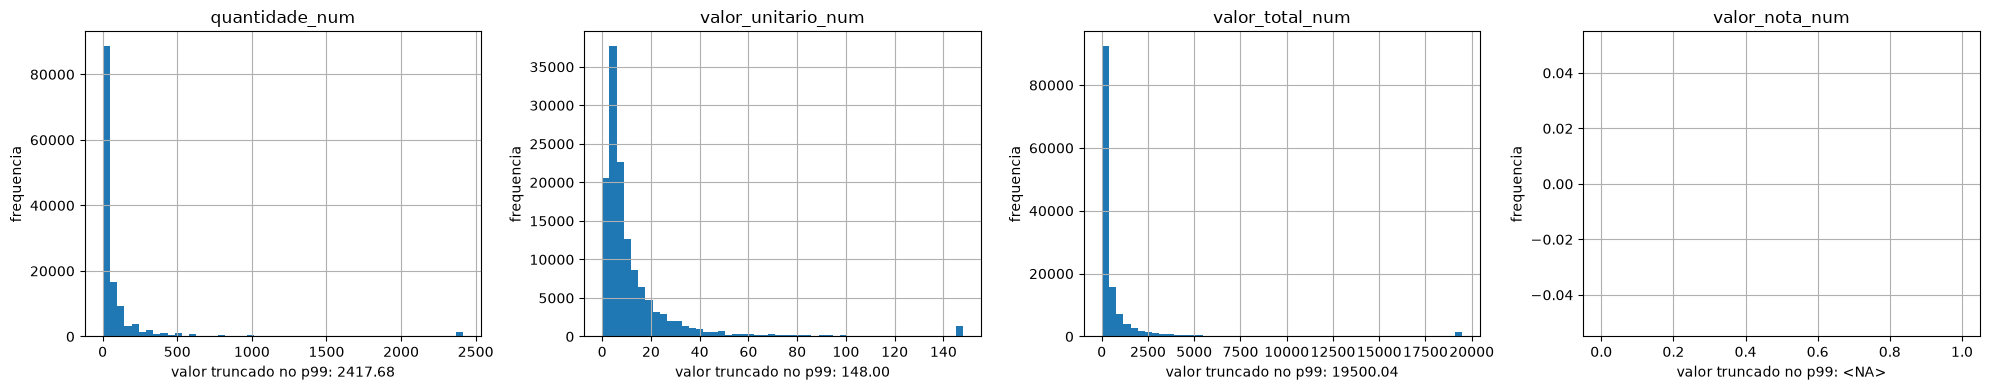

In [28]:
if numeric_cols:
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
    if len(numeric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_cols):
        upper = items[col].quantile(0.99)
        items[col].clip(upper=upper).hist(bins=50, ax=ax)
        ax.set_title(col)
        ax.set_xlabel(f"valor truncado no p99: {upper:.2f}")
        ax.set_ylabel("frequencia")
    plt.tight_layout()
else:
    print("Nenhuma coluna numerica de contexto foi detectada.")

In [29]:
agrupadores_contexto = [col for col in [uf_col, municipio_col, emitente_col, unidade_col] if col]
for col in agrupadores_contexto:
    resumo = (
        items.groupby(col, dropna=False)
        .agg(
            itens=(desc_col, "size"),
            descricoes_unicas=("descricao_limpa_minima", "nunique"),
            ncms_unicos=("ncm_str", "nunique"),
            tamanho_medio_descricao=("descricao_tamanho", "mean"),
        )
        .assign(descricoes_por_100_itens=lambda d: 100 * d["descricoes_unicas"] / d["itens"])
        .sort_values("itens", ascending=False)
        .head(20)
    )
    print(f"\nResumo por {col}")
    display(resumo)


Resumo por UF EMITENTE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
UF EMITENTE,,,,,
PR,15926,2950,363,21.627213,18.523170
RS,14976,2782,326,22.418336,18.576389
PE,11252,1800,335,17.750533,15.997156
MG,9342,2223,330,16.797153,23.795761
RJ,8132,2709,352,24.059887,33.312838
DF,7262,1737,321,24.036078,23.919031
SP,6741,1706,253,19.834891,25.307818
RN,6449,1518,281,22.932238,23.538533
BA,6316,1500,265,18.875871,23.749208



Resumo por MUNICÍPIO EMITENTE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
MUNICÍPIO EMITENTE,,,,,
PATO BRANCO,7603,920,152,21.391161,12.100487
BRASILIA,6692,1497,305,23.823371,22.369994
RIO DE JANEIRO,5474,1610,309,21.737121,29.411765
BOA VISTA,5220,636,207,36.218774,12.183908
NATAL,3963,1111,236,24.84759,28.034317
MANAUS,3825,764,231,18.334118,19.973856
CAMPO GRANDE,3464,740,173,34.821016,21.362587
SANTA MARIA,3384,356,129,12.540189,10.520095
CONTAGEM,3045,201,98,11.966831,6.600985



Resumo por RAZÃO SOCIAL EMITENTE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
RAZÃO SOCIAL EMITENTE,,,,,
COMSABOR COMERCIO DE ALIMENTOS LTDA - ME,5363,606,109,21.140779,11.299646
COMPANHIA NACIONAL DE ABASTECIMENTO,3144,113,29,68.943384,3.594148
ATACADAO S.A.,3104,1814,254,25.584407,58.440722
J E S COML. DE ALIM. LTDA,3055,141,41,23.802619,4.615385
R. R LEGUMES LTDA,2797,85,42,10.190204,3.038970
ZM COMERCIO DE ALIMENTOS LTDA,2662,93,35,8.838092,3.493614
J L C DE MELO,2324,304,133,28.638124,13.080895
BONIBOM COMERCIO DE ALIMENTOS EIRELI,2145,413,100,21.553846,19.254079
JULIANO LUCIO FRANCISCATTO DO AMARAL,1849,59,24,9.399676,3.190914



Resumo por UNIDADE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
UNIDADE,,,,,
KG,66856,5700,450,18.002707,8.525787
UNIDAD,41593,14090,536,26.585147,33.875893
PCT,3386,870,154,29.991435,25.694034
UND9,2277,1551,206,26.393061,68.115942
PEÇA,2100,1185,154,32.160952,56.428571
UN1,2057,1380,233,27.751094,67.087992
KG1,1622,437,100,17.261406,26.942047
LITRO,1247,316,97,26.31676,25.340818
CX,881,415,122,29.893303,47.105562


## Fechamento

Pontos para levar para a escrita do TCC:

- tamanho e cobertura da base antes do preprocessamento;
- evidencia empirica de textos curtos e ruidosos;
- disponibilidade e concentracao dos NCMs;
- casos em que descricao e NCM nao formam uma relacao simples de um-para-um;
- heterogeneidade causada por emitentes, localidades, unidades e padroes de valor.